# 08 — Batsman Pre-Game Report

**Goal**: Generate a complete pre-game intelligence report for any batsman.

**Input**: `data/final_processed_data.csv`, `data/batsman_profiles.csv`, `data/phase_sr.csv`, `data/bowling_success_model.csv`

**Covers**:
1. Overall batting profile
2. Strength zones — where they score most freely
3. Weakness zones — low SR + high dismissal rate simultaneously
4. Shot risk profile — reward vs risk per shot type
5. Phase-wise performance breakdown
6. Performance vs each bowling style
7. Chase vs Set performance (1st vs 2nd innings)
8. Ground-specific performance
9. Pressure performance — under wicket pressure
10. Head-to-head vs specific opposition bowlers
11. Recommended bowling plan to dismiss them

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler
import os, warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR     = os.path.join(PROJECT_ROOT, 'data')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110})

## 1. Load Data

In [77]:
df       = pd.read_csv(os.path.join(DATA_DIR, 'final_processed_data.csv'))
profiles = pd.read_csv(os.path.join(DATA_DIR, 'batsman_profiles.csv'))
phase_sr = pd.read_csv(os.path.join(DATA_DIR, 'phase_sr.csv'))
matchup  = pd.read_csv(os.path.join(DATA_DIR, 'bowling_success_model.csv'))

for c in ['isFour','isSix','isWicket']: df[c] = df[c].astype(int)
df['isBoundary'] = ((df['isFour']==1)|(df['isSix']==1)).astype(int)
df['is_valid']   = ((df['wides']==0)&(df['noballs']==0)).astype(int)
df['match_phase'] = df['oversActual'].apply(
    lambda o: 'Powerplay' if o<=6 else ('Middle' if o<=15 else 'Death'))

profiles['name_key'] = profiles['Full Name'].str.lower().str.strip()

# phase_sr uses Batsman_Name short codes — add Full Name for consistent lookups
if 'Full Name' not in phase_sr.columns:
    name_map = (df[['Batsman_Name','Full Name']].drop_duplicates()
                  .set_index('Batsman_Name')['Full Name'].to_dict())
    phase_sr['Full Name'] = phase_sr['Batsman_Name'].map(name_map).fillna(phase_sr['Batsman_Name'])
    phase_sr.rename(columns={
        'boundary_percentage': 'boundary_pct',
        'dot_ball_percentage': 'dot_ball_pct',
        'wicket_percentage'  : 'wicket_pct'
    }, inplace=True, errors='ignore')
phase_sr['name_key'] = phase_sr['Full Name'].str.lower().str.strip()

# bowling_success_model now uses Full Name (Batsman_Name, Bowler_Name columns)
# after notebook 05 is re-run. Both name columns are already full names.
print(f"Loaded {len(df):,} deliveries | {df['Full Name'].nunique()} batsmen")
print(f"Matchup rows: {len(matchup)} | Sample batsman: {matchup['Batsman_Name'].iloc[0]}")

Loaded 33,029 deliveries | 462 batsmen
Matchup rows: 4936 | Sample batsman: Shardul Thakur


## 2. Core Lookup Helpers

In [78]:
def get_player_df(name):
    """Return all deliveries for a batsman (Full Name substring match)."""
    return df[df['Full Name'].str.lower().str.contains(name.lower(), na=False)]

def get_profile(name):
    """Return profile row for a batsman."""
    return profiles[profiles['name_key'].str.contains(name.lower(), na=False)]

def get_phase_rows(name):
    """Return phase_sr rows for a batsman."""
    return phase_sr[phase_sr['name_key'].str.contains(name.lower(), na=False)]

# Quick test
r = get_player_df('Virat Kohli')
print(f"Virat Kohli deliveries: {len(r)}")

Virat Kohli deliveries: 490


## 3. Strength Zone Analysis

Strength = High SR + High boundary%. These are the zones the batsman exploits.

In [79]:
def strength_zones(name, min_balls=5):
    """
    For each pitch zone (line x length), compute:
    - SR, boundary%, wicket%, dot_pct
    - strength_score = 0.6 * norm_SR + 0.4 * norm_boundary_pct
    Returns sorted DataFrame, top rows = strength zones.
    """
    bat   = get_player_df(name)
    valid = bat[bat['is_valid']==1]
    if valid.empty: return None

    zone = valid.groupby(['pitchLine', 'pitchLength']).agg(
        balls      =('run', 'count'),
        runs       =('run', 'sum'),
        boundaries =('isBoundary', 'sum'),
        wickets    =('isWicket', 'sum'),
        dot_balls  =('run', lambda x: (x == 0).sum())   # compute dot_balls here
    ).reset_index()
    zone = zone[zone['balls'] >= min_balls].copy()

    zone['strike_rate']  = (zone['runs']       / zone['balls'] * 100).round(2)
    zone['boundary_pct'] = (zone['boundaries'] / zone['balls'] * 100).round(2)
    zone['wicket_pct']   = (zone['wickets']    / zone['balls'] * 100).round(2)
    zone['dot_pct']      = (zone['dot_balls']  / zone['balls'] * 100).round(2)  # safe: same index

    scaler = MinMaxScaler()
    if len(zone) > 1:
        zone['sr_norm']   = scaler.fit_transform(zone[['strike_rate']])
        zone['bdry_norm'] = scaler.fit_transform(zone[['boundary_pct']])
        zone['strength_score'] = (0.6 * zone['sr_norm'] + 0.4 * zone['bdry_norm']).round(3)
    else:
        zone['strength_score'] = 0.5

    zone.drop(columns=['sr_norm', 'bdry_norm'], errors='ignore', inplace=True)
    return zone.sort_values('strength_score', ascending=False).reset_index(drop=True)

sz = strength_zones('Virat Kohli')
print("Strength zones for Virat Kohli:")
print(sz[['pitchLine','pitchLength','balls','strike_rate','boundary_pct','wicket_pct','strength_score']].to_string())

Strength zones for Virat Kohli:
                pitchLine             pitchLength  balls  strike_rate  boundary_pct  wicket_pct  strength_score
0           ON_THE_STUMPS               FULL_TOSS      9       300.00         44.44        0.00           1.000
1        OUTSIDE_OFFSTUMP                    FULL     47       193.62         27.66        2.13           0.529
2   WIDE_OUTSIDE_OFFSTUMP             GOOD_LENGTH     10       180.00         30.00        0.00           0.515
3           ON_THE_STUMPS  SHORT_OF_A_GOOD_LENGTH     22       172.73         22.73        0.00           0.420
4           ON_THE_STUMPS                    FULL     58       168.97         18.97        0.00           0.372
5        OUTSIDE_OFFSTUMP               FULL_TOSS      5       160.00         20.00        0.00           0.357
6        OUTSIDE_OFFSTUMP                   SHORT     10       120.00         20.00        0.00           0.244
7   WIDE_OUTSIDE_OFFSTUMP                    FULL      8       137.50   

## 4. Weakness Zone Analysis

Weakness = Low SR + High wicket%. The intersection is the zone to exploit as a bowler.

In [80]:
def weakness_zones(name, min_balls=5):
    """
    weakness_score = 0.6 * (1 - norm_SR) + 0.4 * norm_wicket_pct
    Top rows = biggest weaknesses.
    """
    zone = strength_zones(name, min_balls)
    if zone is None or zone.empty: return None

    scaler = MinMaxScaler()
    if len(zone) > 1:
        zone['inv_sr_norm'] = 1 - scaler.fit_transform(zone[['strike_rate']])
        zone['wkt_norm']    = scaler.fit_transform(zone[['wicket_pct']])
        zone['weakness_score'] = (0.6*zone['inv_sr_norm'] + 0.4*zone['wkt_norm']).round(3)
    else:
        zone['weakness_score'] = 0.5

    zone.drop(columns=['inv_sr_norm','wkt_norm'], errors='ignore', inplace=True)
    return zone.sort_values('weakness_score', ascending=False)

wz = weakness_zones('Virat Kohli')
print("Weakness zones for Virat Kohli:")
print(wz[['pitchLine','pitchLength','balls','strike_rate','wicket_pct','weakness_score']].to_string())

Weakness zones for Virat Kohli:
                pitchLine             pitchLength  balls  strike_rate  wicket_pct  weakness_score
11       OUTSIDE_OFFSTUMP  SHORT_OF_A_GOOD_LENGTH     60       100.00        5.00           0.965
8        OUTSIDE_OFFSTUMP             GOOD_LENGTH    119       112.61        2.52           0.731
9           ON_THE_STUMPS             GOOD_LENGTH     92       110.87        1.09           0.621
10               DOWN_LEG             GOOD_LENGTH      8        87.50        0.00           0.600
6        OUTSIDE_OFFSTUMP                   SHORT     10       120.00        0.00           0.508
1        OUTSIDE_OFFSTUMP                    FULL     47       193.62        2.13           0.471
7   WIDE_OUTSIDE_OFFSTUMP                    FULL      8       137.50        0.00           0.459
5        OUTSIDE_OFFSTUMP               FULL_TOSS      5       160.00        0.00           0.395
4           ON_THE_STUMPS                    FULL     58       168.97        0.00     

## 5. Shot Risk Profile

Which shots yield rewards (boundaries) vs risk (wickets)?

In [81]:
def shot_risk_profile(name, min_balls=10):
    """Returns shot type stats: boundary%, wicket%, avg_runs, risk_reward_ratio."""
    bat  = get_player_df(name)
    valid = bat[bat['is_valid']==1]
    if valid.empty: return None

    shot = valid.groupby('shotType').agg(
        balls      =('run','count'),
        runs       =('run','sum'),
        boundaries =('isBoundary','sum'),
        wickets    =('isWicket','sum')
    ).reset_index()
    shot = shot[shot['balls']>=min_balls].copy()
    shot['avg_runs']    = (shot['runs']/shot['balls']).round(3)
    shot['boundary_pct']= (shot['boundaries']/shot['balls']*100).round(2)
    shot['wicket_pct']  = (shot['wickets']/shot['balls']*100).round(2)
    # Risk-reward: how many runs scored per wicket lost
    shot['risk_reward'] = (shot['avg_runs'] / (shot['wicket_pct']/100 + 1e-6)).round(2)
    shot['shot_type']   = shot['shotType'].str.replace('_',' ').str.title()
    return shot.sort_values('boundary_pct', ascending=False)

srp = shot_risk_profile('Virat Kohli')
print("Shot risk profile — Virat Kohli:")
print(srp[['shot_type','balls','boundary_pct','wicket_pct','avg_runs','risk_reward']].to_string())

Shot risk profile — Virat Kohli:
       shot_type  balls  boundary_pct  wicket_pct  avg_runs  risk_reward
13  Square Drive     19         36.84        0.00     2.105   2105000.00
9           Pull     28         35.71        3.57     2.107        59.02
0    Cover Drive     67         25.37        2.99     1.806        60.40
1       Cut Shot     23         17.39        4.35     1.174        26.99
11     Slog Shot     12         16.67       25.00     1.417         5.67
8       On Drive    102         12.75        0.98     1.343       137.03
4          Flick    115          7.83        0.00     1.287   1287000.00
14       Steered     26          7.69        3.85     1.038        26.96
3       Defended     34          0.00        0.00     0.235    235000.00
10          Push     23          0.00        4.35     0.435        10.00


## 6. Performance vs Bowling Style

In [82]:
def vs_bowling_style(name, min_balls=10):
    """SR and wicket% vs each bowling style."""
    bat  = get_player_df(name)
    valid = bat[bat['is_valid']==1]
    if valid.empty: return None

    vs = valid.groupby('Bowler_Bowling_Style').agg(
        balls      =('run','count'),
        runs       =('run','sum'),
        boundaries =('isBoundary','sum'),
        wickets    =('isWicket','sum')
    ).reset_index()
    vs = vs[vs['balls']>=min_balls].copy()
    vs['strike_rate']  = (vs['runs']/vs['balls']*100).round(2)
    vs['boundary_pct'] = (vs['boundaries']/vs['balls']*100).round(2)
    vs['wicket_pct']   = (vs['wickets']/vs['balls']*100).round(2)
    return vs.sort_values('strike_rate', ascending=False)

vbs = vs_bowling_style('Virat Kohli')
print("vs Bowling Style:")
print(vbs[['Bowler_Bowling_Style','balls','strike_rate','boundary_pct','wicket_pct']].to_string())

vs Bowling Style:
           Bowler_Bowling_Style  balls  strike_rate  boundary_pct  wicket_pct
1          left-arm fast-medium     36       169.44         25.00        2.78
7              right-arm medium     26       157.69         19.23        0.00
8         right-arm medium-fast     25       156.00         20.00        0.00
0                 left-arm fast     31       151.61         22.58        3.23
5                right-arm fast     72       150.00         20.83        1.39
6         right-arm fast-medium     94       145.74         17.02        3.19
9            right-arm offbreak     29       141.38         13.79        3.45
10  right-arm offbreak,legbreak     15       126.67         13.33        0.00
2          left-arm medium-fast     23       113.04         13.04        4.35
11       slow left-arm orthodox     66       104.55          6.06        1.52
4               legbreak googly     22       100.00          9.09        0.00
3                      legbreak     37        

## 7. Chase vs Set Performance

In [83]:
def chase_vs_set(name):
    """Compare performance in 1st innings (setting) vs 2nd innings (chasing)."""
    bat  = get_player_df(name)
    valid = bat[bat['is_valid']==1]
    if valid.empty: return None

    perf = valid.groupby('inningNumber').agg(
        balls      =('run','count'),
        runs       =('run','sum'),
        boundaries =('isBoundary','sum'),
        wickets    =('isWicket','sum')
    ).reset_index()
    perf['strike_rate']  = (perf['runs']/perf['balls']*100).round(2)
    perf['boundary_pct'] = (perf['boundaries']/perf['balls']*100).round(2)
    perf['wicket_pct']   = (perf['wickets']/perf['balls']*100).round(2)
    perf['innings_label']= perf['inningNumber'].map({1:'Setting (1st Inn)',2:'Chasing (2nd Inn)'})
    return perf

cvs = chase_vs_set('Virat Kohli')
print("Chase vs Set — Virat Kohli:")
print(cvs[['innings_label','balls','strike_rate','boundary_pct','wicket_pct']].to_string())

Chase vs Set — Virat Kohli:
       innings_label  balls  strike_rate  boundary_pct  wicket_pct
0  Setting (1st Inn)    302       132.45         14.24        2.65
1  Chasing (2nd Inn)    174       140.23         17.24        1.72


## 8. Pressure Performance

SR when team has lost 0-2 wickets vs 3-5 vs 6+ wickets.

In [84]:
def pressure_performance(name):
    """Analyse how SR changes under wicket pressure."""
    bat  = get_player_df(name)
    valid = bat[bat['is_valid']==1].copy()
    if valid.empty: return None

    valid['pressure_band'] = pd.cut(
        valid['totalWickets'],
        bins=[-1,2,5,10],
        labels=['Low (0-2 wkts)','Medium (3-5 wkts)','High (6+ wkts)'])

    perf = valid.groupby('pressure_band', observed=True).agg(
        balls      =('run','count'),
        runs       =('run','sum'),
        boundaries =('isBoundary','sum'),
        wickets    =('isWicket','sum')
    ).reset_index()
    perf['strike_rate']  = (perf['runs']/perf['balls']*100).round(2)
    perf['boundary_pct'] = (perf['boundaries']/perf['balls']*100).round(2)
    return perf

pp = pressure_performance('Virat Kohli')
print("Pressure Performance — Virat Kohli:")
print(pp[['pressure_band','balls','strike_rate','boundary_pct']].to_string())

Pressure Performance — Virat Kohli:
       pressure_band  balls  strike_rate  boundary_pct
0     Low (0-2 wkts)    263       123.57         12.17
1  Medium (3-5 wkts)    208       146.63         18.75
2     High (6+ wkts)      5       280.00         40.00


## 9. Ground Performance

In [85]:
def ground_performance(name, min_balls=20):
    """SR and boundary% at each ground."""
    bat  = get_player_df(name)
    valid = bat[bat['is_valid']==1]
    if valid.empty: return None

    gnd = valid.groupby('Ground Name').agg(
        balls      =('run','count'),
        runs       =('run','sum'),
        boundaries =('isBoundary','sum'),
        wickets    =('isWicket','sum')
    ).reset_index()
    gnd = gnd[gnd['balls']>=min_balls].copy()
    gnd['strike_rate']  = (gnd['runs']/gnd['balls']*100).round(2)
    gnd['boundary_pct'] = (gnd['boundaries']/gnd['balls']*100).round(2)
    return gnd.sort_values('strike_rate', ascending=False)

gp = ground_performance('Virat Kohli')
print("Ground Performance — Virat Kohli:")
print(gp[['Ground Name','balls','strike_rate','boundary_pct']].to_string() if gp is not None else "Not enough data")

Ground Performance — Virat Kohli:
                                                         Ground Name  balls  strike_rate  boundary_pct
10                                          Wankhede Stadium, Mumbai     46       193.48         26.09
7   Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh     51       164.71         21.57
2                                              Eden Gardens, Kolkata     37       148.65         21.62
8                                              Sydney Cricket Ground     44       140.91         11.36
4                                           Melbourne Cricket Ground     77       136.36         14.29
0                                                      Adelaide Oval     83       136.14         16.87
1                                Dubai International Cricket Stadium     68       100.00          8.82
3                                   M Chinnaswamy Stadium, Bangalore     24       100.00          4.17
9               Vidarbha Cricket Associ

## 10. Head-to-Head vs Opposition Bowlers

In [86]:
def head_to_head(batsman_name, bowler_names=None, top_n=10):
    """
    Return bowlers ranked by success_index_scaled against this batsman.
    Uses whatever columns exist in bowling_success_model.csv — works with
    both old (short-code) and new (full-name) versions of the file.
    """
    key  = batsman_name.lower().strip()
    mask = matchup['Batsman_Name'].str.lower().str.contains(key, na=False, regex=False)
    sub  = matchup[mask].copy()

    if sub.empty:
        print(f"No matchup data found for '{batsman_name}'")
        return None

    if bowler_names:
        b_lower = [b.lower() for b in bowler_names]
        bm = sub['Bowler_Name'].str.lower().apply(
            lambda n: any(b in n for b in b_lower))
        if bm.any():
            sub = sub[bm]
        else:
            print("No data for those bowlers — showing overall top.")

    # Select only columns that actually exist in this CSV
    want = ['Bowler_Name', 'Bowler_Bowling_Style', 'balls_bowled',
            'economy_rate', 'wicket_percentage', 'dot_ball_percentage',
            'success_index_scaled', 'performance_label']
    cols = [c for c in want if c in sub.columns]
    return sub.nlargest(top_n, 'success_index_scaled')[cols]

h2h = head_to_head('Virat Kohli')
print("Best bowlers vs Virat Kohli:")
print(h2h.to_string(index=False) if h2h is not None else "No data")

Best bowlers vs Virat Kohli:
     Bowler_Name   Bowler_Bowling_Style  balls_bowled  economy_rate  success_index_scaled performance_label
      Mark Adair  right-arm fast-medium             4         0.000                0.9546      High Success
   Sean Williams slow left-arm orthodox             4         1.500                0.8012      High Success
       Ish Sodhi               legbreak             4         4.500                0.7330  Moderate Success
      Sam Curran   left-arm medium-fast             6         2.000                0.6137  Moderate Success
      Adam Milne         right-arm fast             9         2.667                0.5455  Moderate Success
   Shuvagata Hom     right-arm offbreak             7         6.857                0.5455  Moderate Success
Mitchell Santner slow left-arm orthodox            11         3.273                0.5207  Moderate Success
      Adam Zampa        legbreak googly             6         3.000                0.5114  Moderate Success

## 11. Full Pre-Game Report Function

In [87]:
def batsman_pregame_report(name):
    """
    Prints and returns a complete pre-game intelligence report.
    """
    bat = get_player_df(name)
    if bat.empty:
        print(f"No data found for '{name}'")
        return

    full_name = bat['Full Name'].iloc[0]
    valid = bat[bat['is_valid']==1]
    runs   = valid['run'].sum()
    balls  = len(valid)
    wkts   = valid['isWicket'].sum()
    bdry   = valid['isBoundary'].sum()
    sr     = round(runs/balls*100, 2) if balls>0 else 0
    avg    = round(runs/wkts, 2) if wkts>0 else float('nan')
    b_pct  = round(bdry/balls*100, 2) if balls>0 else 0

    wz = weakness_zones(name)
    sz = strength_zones(name)
    vbs = vs_bowling_style(name)

    print("="*65)
    print(f"  BATSMAN PRE-GAME REPORT — {full_name.upper()}")
    print("="*65)
    print(f"  Total Runs: {runs}  |  Balls: {balls}  |  SR: {sr}")
    print(f"  Average: {avg}  |  Boundary%: {b_pct}%  |  Wickets: {wkts}")
    print()

    if sz is not None and not sz.empty:
        top_s = sz.iloc[0]
        print(f"  STRENGTH ZONE  : {top_s['pitchLine']} x {top_s['pitchLength']}")
        print(f"                   SR={top_s['strike_rate']}  Boundary%={top_s['boundary_pct']}%")

    if wz is not None and not wz.empty:
        top_w = wz.iloc[0]
        print(f"  WEAKNESS ZONE  : {top_w['pitchLine']} x {top_w['pitchLength']}")
        print(f"                   SR={top_w['strike_rate']}  Wicket%={top_w['wicket_pct']}%")

    if vbs is not None and not vbs.empty:
        best_style  = vbs.iloc[0]['Bowler_Bowling_Style']
        worst_style = vbs.iloc[-1]['Bowler_Bowling_Style']
        print(f"  BEST vs STYLE  : {best_style} (SR={vbs.iloc[0]['strike_rate']})")
        print(f"  WORST vs STYLE : {worst_style} (SR={vbs.iloc[-1]['strike_rate']})")

    print("="*65)

batsman_pregame_report('Virat Kohli')
batsman_pregame_report('MS Dhoni')
batsman_pregame_report('Babar Azam')

  BATSMAN PRE-GAME REPORT — VIRAT KOHLI
  Total Runs: 644  |  Balls: 476  |  SR: 135.29
  Average: 58.55  |  Boundary%: 15.34%  |  Wickets: 11

  STRENGTH ZONE  : ON_THE_STUMPS x FULL_TOSS
                   SR=300.0  Boundary%=44.44%
  WEAKNESS ZONE  : OUTSIDE_OFFSTUMP x SHORT_OF_A_GOOD_LENGTH
                   SR=100.0  Wicket%=5.0%
  BEST vs STYLE  : left-arm fast-medium (SR=169.44)
  WORST vs STYLE : legbreak (SR=91.89)
  BATSMAN PRE-GAME REPORT — MS DHONI
  Total Runs: 86  |  Balls: 69  |  SR: 124.64
  Average: 86.0  |  Boundary%: 10.14%  |  Wickets: 1

  STRENGTH ZONE  : OUTSIDE_OFFSTUMP x GOOD_LENGTH
                   SR=129.41  Boundary%=11.76%
  WEAKNESS ZONE  : ON_THE_STUMPS x GOOD_LENGTH
                   SR=104.55  Wicket%=4.55%
  BEST vs STYLE  : right-arm fast-medium (SR=150.0)
  WORST vs STYLE : right-arm fast-medium (SR=150.0)
  BATSMAN PRE-GAME REPORT — BABAR AZAM
  Total Runs: 528  |  Balls: 457  |  SR: 115.54
  Average: 35.2  |  Boundary%: 12.04%  |  Wickets: 15



## 12. Visualisations

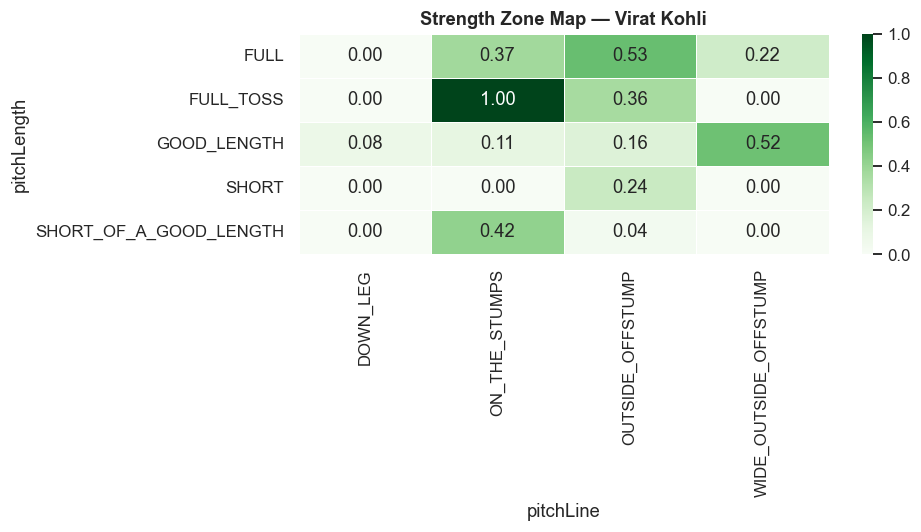

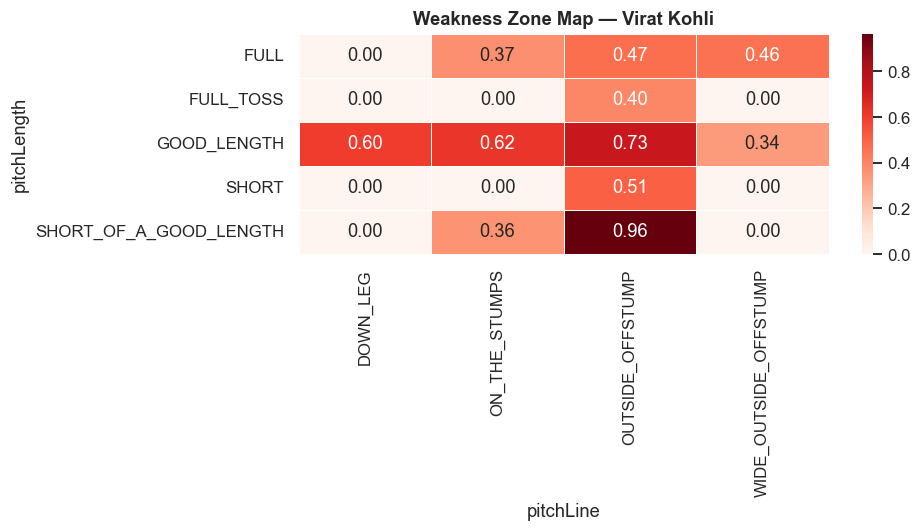

In [88]:
# Strength zone heatmap
def plot_zone_heatmap(name, metric='strength_score', title_prefix='Strength'):
    zone = strength_zones(name) if 'strength' in title_prefix.lower() else weakness_zones(name)
    if zone is None or zone.empty: print(f"No data for {name}"); return
    pivot = zone.pivot_table(metric, index='pitchLength', columns='pitchLine').fillna(0)
    cmap  = 'Greens' if 'strength' in title_prefix.lower() else 'Reds'
    plt.figure(figsize=(9,5))
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap=cmap, linewidths=0.5)
    plt.title(f"{title_prefix} Zone Map — {name}", fontweight='bold')
    plt.tight_layout(); plt.show()

plot_zone_heatmap('Virat Kohli', 'strength_score', 'Strength')
plot_zone_heatmap('Virat Kohli', 'weakness_score', 'Weakness')

In [89]:
# Shot risk scatter — boundary% vs wicket%
def plot_shot_risk(name):
    srp = shot_risk_profile(name)
    if srp is None or srp.empty: return
    fig = px.scatter(srp, x='wicket_pct', y='boundary_pct',
                     size='balls', text='shot_type',
                     color='risk_reward', color_continuous_scale='RdYlGn',
                     title=f"Shot Risk Profile — {name}",
                     labels={'wicket_pct':'Wicket %','boundary_pct':'Boundary %',
                             'risk_reward':'Risk-Reward'})
    fig.update_traces(textposition='top center')
    fig.show()
plot_shot_risk('Virat Kohli')

In [90]:
# vs Bowling Style bar
def plot_vs_style(name):
    vbs = vs_bowling_style(name)
    if vbs is None or vbs.empty: return
    fig = px.bar(vbs.sort_values('strike_rate'), y='Bowler_Bowling_Style', x='strike_rate',
                 orientation='h', color='wicket_pct', color_continuous_scale='RdYlGn_r',
                 title=f"{name} — SR vs Each Bowling Style (colour = wicket%)",
                 text=vbs.sort_values('strike_rate')['strike_rate'])
    fig.update_traces(textposition='outside')
    fig.update_layout(coloraxis_showscale=True, yaxis_title='')
    fig.show()
plot_vs_style('Virat Kohli')

In [91]:
# Phase SR grouped bar for this specific player
def plot_phase_sr(name):
    rows = get_phase_rows(name)
    if rows.empty: print(f"No phase data for {name}"); return
    rows['match_phase'] = pd.Categorical(rows['match_phase'],['Powerplay','Middle','Death'],ordered=True)
    rows = rows.sort_values('match_phase')
    fig = make_subplots(rows=1, cols=3,
        subplot_titles=['Strike Rate','Boundary %','Dot Ball %'])
    colors = {'Powerplay':'#2ecc71','Middle':'#e67e22','Death':'#e74c3c'}
    for i, col in enumerate(['strike_rate','boundary_pct','dot_ball_pct'], 1):
        for _, row in rows.iterrows():
            fig.add_trace(go.Bar(x=[row['match_phase']], y=[round(row[col],1)],
                                 name=row['match_phase'], marker_color=colors[row['match_phase']],
                                 showlegend=(i==1)),
                          row=1, col=i)
    fig.update_layout(title=f"Phase Breakdown — {name}", barmode='group', height=400)
    fig.show()
plot_phase_sr('Virat Kohli')

In [92]:
# Chase vs Set
def plot_chase_vs_set(name):
    cvs = chase_vs_set(name)
    if cvs is None: return
    fig = px.bar(cvs, x='innings_label',
                 y=['strike_rate','boundary_pct'],
                 barmode='group',
                 title=f"Chase vs Set Performance — {name}",
                 labels={'value':'Rate','variable':'Metric','innings_label':''})
    fig.show()
plot_chase_vs_set('Virat Kohli')

In [93]:
# Pressure performance
def plot_pressure(name):
    pp = pressure_performance(name)
    if pp is None: return
    fig = px.bar(pp, x='pressure_band', y='strike_rate',
                 color='strike_rate', color_continuous_scale='RdYlGn',
                 title=f"SR Under Wicket Pressure — {name}",
                 text=pp['strike_rate'])
    fig.update_traces(textposition='outside')
    fig.update_layout(coloraxis_showscale=False)
    fig.show()
plot_pressure('Virat Kohli')

In [94]:
def plot_h2h(name, top_n=10):
    h2h = head_to_head(name, top_n=top_n)
    if h2h is None: return
    # Only pass hover columns that actually exist in the returned dataframe
    hover_cols = [c for c in ['economy_rate','wicket_percentage','dot_ball_percentage']
                  if c in h2h.columns]
    fig = px.bar(h2h, x='Bowler_Name', y='success_index_scaled',
                 color='Bowler_Bowling_Style',
                 title=f"Most Effective Bowlers vs {name}",
                 hover_data=hover_cols,
                 text=h2h['success_index_scaled'].round(3))
    fig.update_traces(textposition='outside')
    fig.update_layout(xaxis_tickangle=-35)
    fig.show()

plot_h2h('Virat Kohli')